# HCDE 530 — Pandas Analysis of the Star Catalog

This notebook explores the HYG v4.2 star catalog (~119,626 real stars). The dataset includes columns like `proper`, `ra`, `dec`, `dist`, `mag`, `absmag`, `lum`, `ci`, `spect`, `con`, and 3D coordinates `x`, `y`, `z`.

The goal is to load the data, get a feel for what it contains, and start narrowing it down to the subset that matters for a constellation generator — the stars actually bright enough for a human to see.

## Setup

Import the libraries and load the catalog into a DataFrame called `df`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('MP1 for Pandas Stars file.csv')

## Initial inspection

Before doing anything analytical, I want to confirm the file loaded correctly, see what each column looks like, and find out where missing values live.

In [8]:
# What does the dataset actually look like at a glance — what are the first few stars in the catalog,
# and what kinds of values fill each column? This helps me confirm I loaded the right file and gives me
# a feel for the units and formats (e.g., ra/dec as decimal degrees, magnitudes as floats, proper names
# only filled in for famous stars).
df.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,bayer,flam,con,comp,comp_primary,base,lum,var,var_min,var_max
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,NaN,NaN,1,0,NaN,1.000000,NaN,NaN,NaN
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,NaN,Psc,1,1,NaN,9.638290,NaN,NaN,NaN
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,NaN,Cet,1,2,NaN,0.392283,NaN,NaN,NaN
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,NaN,And,1,3,NaN,386.901132,NaN,NaN,NaN
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,NaN,Phe,1,4,NaN,9.366989,NaN,NaN,NaN


In [9]:
# How big is this dataset, what is the data type of each column, and how many non-null values does each
# column have? This tells me which columns are numeric (and safe to do math on, like dist or absmag) versus
# text (like spect or proper), and gives me a first hint of where missing data lives — any column with a
# non-null count below the total row count has gaps I'll need to handle.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119626 entries, 0 to 119625
Data columns (total 37 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            119626 non-null  int64  
 1   hip           117951 non-null  float64
 2   hd            98885 non-null   float64
 3   hr            9041 non-null    float64
 4   gl            3801 non-null    str    
 5   bf            3099 non-null    str    
 6   proper        499 non-null     str    
 7   ra            119626 non-null  float64
 8   dec           119626 non-null  float64
 9   dist          119626 non-null  float64
 10  pmra          119626 non-null  float64
 11  pmdec         119626 non-null  float64
 12  rv            119626 non-null  float64
 13  mag           119626 non-null  float64
 14  absmag        119626 non-null  float64
 15  spect         116578 non-null  str    
 16  ci            117735 non-null  float64
 17  x             119626 non-null  float64
 18  y             1

In [10]:
# Which columns have missing values, and how many rows are affected in each? This matters because missing
# data limits the kinds of questions I can ask. For example, stars without a 'proper' name can't be
# identified by common name, stars without 'spect' can't be grouped by spectral class, and stars with
# missing 'ci' (color index) can't be plotted on a color–magnitude diagram. Knowing the scale of the gaps
# up front tells me whether I can safely drop those rows or whether I need to filter to the subset of
# stars that have the attribute I care about.
df.isnull().sum()

id                   0
hip               1675
hd               20741
hr              110585
gl              115825
bf              116527
proper          119127
ra                   0
dec                  0
dist                 0
pmra                 0
pmdec                0
rv                   0
mag                  0
absmag               0
spect             3048
ci                1891
x                    0
y                    0
z                    0
vx                   0
vy                   0
vz                   0
rarad                0
decrad               0
pmrarad              0
pmdecrad             0
bayer           118089
flam            116889
con                  1
comp                 0
comp_primary         0
base            118540
lum                  0
var             113634
var_min         102635
var_max         102635
dtype: int64

## Filtering to stars visible to the human eye

The catalog has ~119k stars, but most are far too dim to see without a telescope. For a constellation generator I only care about stars a person could actually look up and notice — the traditional cutoff for naked-eye visibility is apparent magnitude `mag < 6.5`.

In [11]:
# I'm asking: which stars are actually bright enough to be seen and form constellations? The full catalog
# has ~119,626 stars, but the vast majority are far too faint for the naked eye. Filtering to mag < 6.5
# (the human-eye visibility limit) tells me how many of those catalog stars are realistically usable for
# a constellation generator — i.e., how many stars a person standing under a dark sky could ever actually
# see and connect into shapes. Comparing df.shape to visible_df.shape shows just how dramatically the
# usable population shrinks once I apply that real-world brightness cutoff.
print('Before filter:', df.shape)
visible_df = df[df['mag'] < 6.5]
print('After filter: ', visible_df.shape)

Before filter: (119626, 37)
After filter:  (8835, 37)


In [12]:
# I'm asking: which constellations contain the most visible stars? Each star is tagged with a
# constellation abbreviation in the 'con' column, so counting visible stars per constellation reveals
# how the night sky is actually distributed for a naked-eye observer. Some constellations will turn
# out to be unusually star-rich (often the big ones along the Milky Way like Centaurus, Orion, or
# Carina), while others — the small or sparse ones — will have only a handful of bright stars. This
# uneven distribution is exactly what a constellation generator has to work with: not every region of
# the sky offers the same raw material.
visible_df['con'].value_counts().head(20)

con
Cen    282
Cyg    270
Her    243
Pup    242
Hya    241
Car    224
Tau    222
Vel    214
Dra    214
UMa    209
Ori    203
Eri    196
Sgr    195
Cet    194
Peg    178
Oph    176
Aqr    174
Vir    172
Sco    171
Per    161
Name: count, dtype: int64

## Question 1: clustering stars into constellation-like groups

If I ignore the official constellation labels and only look at *where* stars sit in the sky, do natural groupings emerge that look anything like the 88 official constellations? Here I run K-Means on `ra` and `dec` with `k=88` to test whether proximity alone is enough to recover something constellation-like.

In [13]:
from sklearn.cluster import KMeans

# I'm asking: if I ignore the official constellation labels and just group stars purely by where
# they sit in the sky (right ascension and declination), do I end up with 88 spatial groups that
# look anything like real constellations? K-Means with k=88 forces the algorithm to carve the sky
# into 88 convex blobs based on Euclidean distance in (ra, dec). If proximity alone is enough to
# recover constellation-like structure, the resulting clusters should roughly tile the sky the way
# astronomers historically grouped stars. Caveat: ra wraps around at 0/24h and the sky is a sphere,
# so K-Means in flat (ra, dec) space is an approximation — clusters near ra=0 will get artificially
# split, and clusters near the poles will be distorted.
visible_df = visible_df.copy()
kmeans = KMeans(n_clusters=88, random_state=42, n_init=10)
visible_df['cluster'] = kmeans.fit_predict(visible_df[['ra', 'dec']])
visible_df[['proper', 'ra', 'dec', 'mag', 'con', 'cluster']].head()

,proper,ra,dec,mag,con,cluster
0,Sol,0.000000,0.000000,-26.70,NaN,34
25,NaN,0.005300,-44.290561,6.28,Phe,70
34,NaN,0.006638,26.918108,6.43,Peg,80
43,NaN,0.008593,59.559679,6.18,Cas,27
50,NaN,0.009533,-53.097713,6.49,Phe,19


In [14]:
# I'm asking: what does each spatial cluster actually look like — where is its center in the sky,
# and how many visible stars did it pull in? Computing the mean ra and mean dec per cluster gives me
# the "center of mass" of each group, and the count tells me how dense each region of the sky is.
# Showing the top 10 largest clusters reveals whether K-Means is finding evenly sized groups (which
# would suggest the sky is fairly uniform) or whether a few clusters dominate (which would point to
# real density variations like the Milky Way band, where visible stars genuinely pile up).
cluster_summary = visible_df.groupby('cluster').agg(
    mean_ra=('ra', 'mean'),
    mean_dec=('dec', 'mean'),
    star_count=('ra', 'count')
).sort_values('star_count', ascending=False)

cluster_summary.head(10)

,mean_ra,mean_dec,star_count
cluster,,,
77,19.947923,1.159595,158
34,3.936299,0.285138,157
8,19.296321,31.635282,154
13,7.619611,-36.654592,151
54,7.339289,-21.593525,150
29,9.671060,-59.400855,146
1,14.512995,-49.764048,143
51,14.990154,-42.171289,140
23,6.754895,-4.210097,139


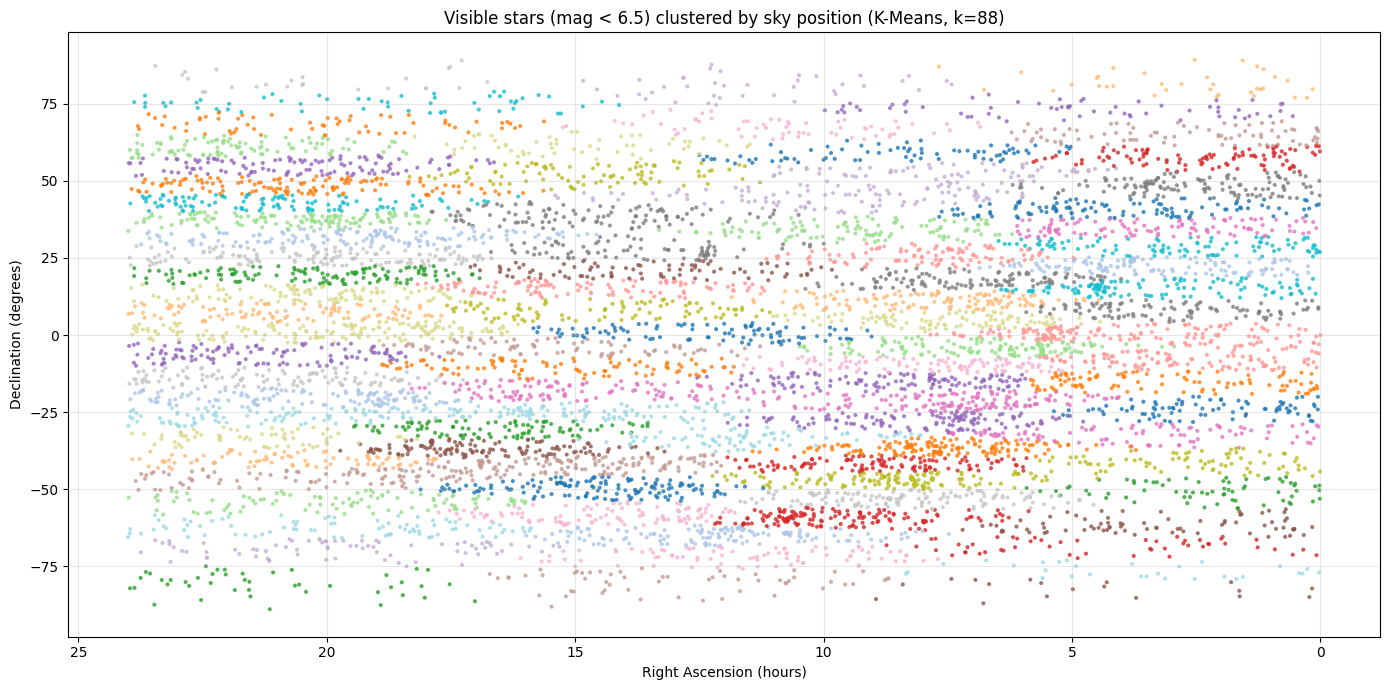

In [ ]:
# I'm asking: visually, does this look anything like the night sky carved into constellation-shaped
# regions? Plotting every visible star's ra vs dec and coloring by cluster lets me eyeball whether
# K-Means produced 88 coherent patches of sky (good — proximity recovers something constellation-like)
# or whether the clusters are weirdly stretched, fragmented near ra=0, or distorted near the poles
# (a sign that flat-space K-Means is fighting the spherical geometry of the real sky). I invert the
# ra axis so the plot reads east-to-west the way the sky actually appears when you look up.
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    visible_df['ra'],
    visible_df['dec'],
    c=visible_df['cluster'],
    cmap='tab20',
    s=4,
    alpha=0.7
)
ax.invert_xaxis()
ax.set_xlabel('Right Ascension (hours)')
ax.set_ylabel('Declination (degrees)')
ax.set_title('Visible stars (mag < 6.5) clustered by sky position (K-Means, k=88)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 2: Do brighter stars form the main structure?

Constellations as we recognize them are usually traced out by the *brightest* stars in a region of sky — the dim ones fill in the background but don't define the shape. Here I want to check, cluster by cluster, whether each group has a small set of bright "anchor" stars surrounded by many dim ones. If that pattern holds, it supports the idea that the human-recognized shape of a constellation is driven by a handful of very bright stars rather than the full population of stars in that patch of sky.

In [16]:
# Question I'm asking: on average, how bright are the stars inside each cluster?
# In astronomy magnitude is inverted — smaller mag = brighter star — so a cluster with a
# *low* mean mag is dominated by genuinely bright, eye-catching stars, while a cluster
# with a *high* mean mag is mostly faint stars near the visibility limit. The mean alone
# won't tell me the shape of the distribution, but it gives a quick first read on whether
# any clusters look "anchored" by bright stars vs. being mostly dim filler.
mean_mag_per_cluster = visible_df.groupby('cluster')['mag'].mean()
mean_mag_per_cluster.sort_values().head(10)

cluster
47    5.425267
81    5.442857
59    5.448716
87    5.455043
51    5.466500
6     5.471333
46    5.479114
44    5.496395
63    5.505317
33    5.510702
Name: mag, dtype: float64

In [17]:
# Question I'm asking: which stars in this catalog count as "clearly visible / bright" to a
# casual observer? Magnitude < 3.0 is a common rough threshold for stars that stand out
# even from a city sky and that people would actually use to draw a constellation shape.
# I tag each star with a True/False flag so I can later count, per cluster, how many of
# these structural-anchor stars there are vs. how many are dim background stars.
visible_df['is_bright'] = visible_df['mag'] < 3.0
visible_df['is_bright'].value_counts()

is_bright
False    8660
True      175
Name: count, dtype: int64

In [18]:
# Question I'm asking: how many genuinely bright "anchor" stars does each cluster contain?
# If the constellation-shape theory is right, I'd expect most clusters to have only a
# handful of bright stars (often just 2–8) surrounded by hundreds of dim ones — meaning
# the recognizable shape of a constellation is carried by a small bright skeleton, not by
# the full crowd of stars in that patch of sky. A flat distribution where every cluster
# has dozens of bright stars would argue against that, so this count is a direct test.
bright_per_cluster = visible_df.groupby('cluster')['is_bright'].sum()
bright_per_cluster.sort_values(ascending=False).head(20)

cluster
47    7
87    6
71    6
59    6
1     6
27    5
53    5
44    5
6     5
75    4
66    4
56    4
51    4
20    4
34    4
8     3
23    3
83    3
79    3
63    3
Name: is_bright, dtype: int64

In [19]:
# Question I'm asking: if I zoom into the cluster that lands roughly where Orion lives in
# the sky (RA ~5–6h, Dec near 0°), do its brightest stars actually look like the famous
# Orion stars (Betelgeuse, Rigel, Bellatrix, the belt, etc.)? I'm checking whether the
# top of the brightness ranking inside one positionally-defined cluster matches the
# stars a human would actually use to draw that constellation. If the brightest 10 are
# real named Orion stars, that's strong evidence that brightness + position together
# recover the human-recognized shape.
cluster_centers = visible_df.groupby('cluster')[['ra', 'dec']].mean()
orion_ra, orion_dec = 5.5, 0.0
distances = np.sqrt((cluster_centers['ra'] - orion_ra) ** 2 + (cluster_centers['dec'] - orion_dec) ** 2)
orion_cluster = distances.idxmin()
print(f"Closest cluster to Orion's rough position: {orion_cluster}")
print(f"Cluster center: RA={cluster_centers.loc[orion_cluster, 'ra']:.2f}h, "
      f"Dec={cluster_centers.loc[orion_cluster, 'dec']:.2f}°")

orion_stars = visible_df[visible_df['cluster'] == orion_cluster].sort_values('mag').head(10)
orion_stars[['proper', 'bf', 'bayer', 'con', 'ra', 'dec', 'mag', 'spect']]

Closest cluster to Orion's rough position: 34
Cluster center: RA=3.94h, Dec=0.29°


,proper,bf,bayer,con,ra,dec,mag,spect
0,Sol,NaN,NaN,NaN,0.000000,0.000000,-26.70,G2V
26246,Alnilam,46Eps Ori,Eps,Ori,5.603559,-1.201920,1.69,B0Ia
25865,Mintaka,34Del Ori,Del,Ori,5.533445,-0.299092,2.25,O9.5II
14100,Menkar,92Alp Cet,Alp,Cet,3.037992,4.089734,2.54,M2III
12673,Kaffaljidhma,86Gam Cet,Gam,Cet,2.721678,3.235818,3.47,A3V
22744,NaN,8Pi 5Ori,Pi-5,Ori,4.904193,2.440672,3.71,B2III SB
9467,Alrescha,113Alp Psc,Alp,Psc,2.034117,2.763759,3.82,A2
12355,NaN,82Del Cet,Del,Cet,2.658044,0.328511,4.08,B2IV
34677,NaN,22Del Mon,Del,Mon,7.197739,-0.492764,4.15,A2V
16811,NaN,10 Tau,NaN,Tau,3.614551,0.401662,4.29,F9V


## Question 3: What properties characterize different clusters?

Position alone tells me where stars sit on the sky. Brightness tells me which ones humans actually see. But stars also differ in **temperature** (color), **luminosity** (intrinsic energy output), and **spectral class** (a letter from O→M that summarizes surface temperature: O is hottest blue, M is coolest red).

The question here is whether the spatial clusters K-Means produced are **astrophysically homogeneous** — i.e. do certain regions of the sky genuinely host hotter or cooler populations of stars? If yes, the night sky isn't just a uniform sprinkle of random stars; different "neighborhoods" have different stellar demographics.

In [20]:
# Question I'm asking: are some sky regions dominated by hot blue stars while others are
# dominated by cool red stars? The B-V color index (`ci`) is a temperature proxy: lower (and
# negative) values mean hotter, bluer stars (think Rigel, Spica), while higher values mean
# cooler, redder stars (think Betelgeuse, Antares). I'm taking the mean `ci` and mean `lum`
# (luminosity in solar units) per cluster, then looking at the 5 clusters with the lowest
# average `ci` (hottest neighborhoods) and the 5 with the highest (coolest neighborhoods).
# If the hot clusters cluster around the galactic plane (where young, massive blue stars are
# born) and the cool clusters are scattered elsewhere, that's evidence that "where you look"
# in the sky genuinely changes "what kind of star you tend to see."

cluster_properties = visible_df.groupby('cluster').agg(
    mean_ci=('ci', 'mean'),
    mean_lum=('lum', 'mean'),
    star_count=('ci', 'count')
).round(3)

print("Top 5 HOTTEST clusters (lowest mean B-V color index → bluer stars):")
print(cluster_properties.sort_values('mean_ci').head(5))
print()
print("Top 5 COOLEST clusters (highest mean B-V color index → redder stars):")
print(cluster_properties.sort_values('mean_ci', ascending=False).head(5))

Top 5 HOTTEST clusters (lowest mean B-V color index → bluer stars):
         mean_ci     mean_lum  star_count
cluster                                  
73         0.374  5901627.985         137
51         0.454  1552954.658         139
5          0.460  4352399.390         135
47         0.472  1509488.848         129
1          0.475   933027.144         143

Top 5 COOLEST clusters (highest mean B-V color index → redder stars):
         mean_ci    mean_lum  star_count
cluster                                 
84         0.902      92.980          29
58         0.831     134.541          64
42         0.812     101.699         101
22         0.811      97.328         112
39         0.810  529282.586         116


In [21]:
# Question I'm asking: which spectral classes (the broad O/B/A/F/G/K/M temperature
# categories) actually dominate the stars humans can see? The `spect` column has detailed
# spectral types like "G2V" or "M1Iab" — I only need the leading letter, which encodes
# surface temperature on the standard Harvard scale (O hottest blue → M coolest red, with
# our Sun being a G). I'm pulling the first character into `spect_class` and counting how
# common each letter is in the visible sky. If the visible sky is mostly K and M class
# stars, that tells me cool stars dominate by count even though hot O/B stars get all the
# attention because they're so luminous they shine across huge distances.

visible_df = visible_df.copy()
visible_df['spect_class'] = visible_df['spect'].str[0]
print("Spectral class distribution in visible sky:")
print(visible_df['spect_class'].value_counts())

Spectral class distribution in visible sky:
spect_class
K    2449
A    1809
B    1637
F    1198
G    1138
M     516
O      52
C      17
W       5
S       3
d       3
N       2
p       1
Name: count, dtype: int64


In [22]:
# Question I'm asking: zooming in on each cluster, what's the *most common* spectral class
# inside it? Mean `ci` from part (a) gives me a continuous temperature average, but the
# mode of `spect_class` tells me the dominant *type* of star in that patch of sky. If
# different clusters consistently come back with different modes — some K-dominated, some
# A-dominated, a few B-dominated — that means K-Means didn't just slice the sky into
# arbitrary boxes; the spatial neighborhoods it found actually correspond to different
# stellar populations. If instead almost every cluster's mode is K or M, that tells me
# cool stars are so numerous they win the popularity contest in nearly every region, and
# the hotter spectral classes only show up as rare individuals.

dominant_spect = (
    visible_df.groupby('cluster')['spect_class']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown')
    .rename('dominant_spect_class')
)

print("Distribution of dominant spectral class across the 88 clusters:")
print(dominant_spect.value_counts())
print()
print("Sample of clusters and their dominant spectral class:")
print(dominant_spect.head(15))

Distribution of dominant spectral class across the 88 clusters:
dominant_spect_class
K    55
B    17
A    13
G     2
F     1
Name: count, dtype: int64

Sample of clusters and their dominant spectral class:
cluster
0     K
1     B
2     K
3     K
4     K
5     B
6     A
7     K
8     K
9     K
10    K
11    K
12    K
13    B
14    A
Name: dominant_spect_class, dtype: str


## Custom Constellation: The Cat

I'm designing a brand-new constellation called **Felis** by picking real stars from the HYG catalog and connecting them in the shape of a sitting cat. The plan: pick one coherent patch of sky, sketch the cat's anatomy as target coordinates, find the nearest (and ideally brightest) real star for each body part, then draw the connecting lines.

In [29]:
# Question: which patch of sky should we draw the cat on?
# A constellation has to be a coherent shape — the eye, ear, paw, and tail need to sit
# in the same patch of sky, otherwise an observer can't trace the figure in one glance.
# Constraining to a single ~30° x 30° region also keeps the line distances between body
# parts consistent. I'm picking the area around Orion (ra 4.5h–6.5h, dec -15°…+15°)
# because Question 2 already showed it's dense in bright stars (Betelgeuse, Rigel,
# Bellatrix, the Belt), so the cat's outline will land on real, recognizable stars.

ra_min, ra_max = 4.5, 6.5      # hours; 2 h of RA = 30°
dec_min, dec_max = -15, 15     # degrees

cat_region = visible_df[
    (visible_df['ra']  >= ra_min)  & (visible_df['ra']  <= ra_max) &
    (visible_df['dec'] >= dec_min) & (visible_df['dec'] <= dec_max)
].copy()

print(f"Stars in cat region: {len(cat_region)}")
print(f"  of which mag < 4.5 (clearly visible): {(cat_region['mag'] < 4.5).sum()}")
print(f"  of which mag < 3.0 (anchor-bright):   {(cat_region['mag'] < 3.0).sum()}")

Stars in cat region: 303
  of which mag < 4.5 (clearly visible): 42
  of which mag < 3.0 (anchor-bright):   9


In [31]:
# Question: where does each part of the cat go in sky coordinates, before we look at
# any real stars?
# I'm laying out the cat's silhouette as target (ra_hours, dec_deg) points first.
# This way the cat shape is decided by anatomy, not by which random stars happen to
# be available — afterward I'll match each target to the nearest real star.
# Layout: cat is sitting in profile facing right (toward the right edge of the chart
# *after* the standard astronomical RA-axis flip), with head up top, body in the
# middle, paws below, and tail curling up behind.

cat_anatomy = {
    'left_ear_tip':   (5.10,  12.0),   # back ear, slightly higher RA
    'right_ear_tip':  (4.80,  12.0),   # front ear, slightly lower RA
    'left_eye':       (5.00,   8.0),
    'right_eye':      (4.70,   8.0),
    'nose':           (4.55,   5.0),   # snout points "right" (lower RA)
    'chin':           (4.75,   2.0),
    'neck':           (5.05,   0.0),
    'front_shoulder': (5.25,  -2.0),
    'back_shoulder':  (5.70,  -2.0),
    'front_paw':      (5.25, -10.0),
    'back_paw':       (5.70, -10.0),
    'tail_base':      (5.95,   0.0),
    'tail_mid':       (6.20,   5.0),
    'tail_tip':       (6.40,  11.0),
}

print(f"Sketched {len(cat_anatomy)} cat body parts:")
for part, (r, d) in cat_anatomy.items():
    print(f"  {part:16s} target ra={r:.2f}h, dec={d:+.1f}°")

Sketched 14 cat body parts:
  left_ear_tip     target ra=5.10h, dec=+12.0°
  right_ear_tip    target ra=4.80h, dec=+12.0°
  left_eye         target ra=5.00h, dec=+8.0°
  right_eye        target ra=4.70h, dec=+8.0°
  nose             target ra=4.55h, dec=+5.0°
  chin             target ra=4.75h, dec=+2.0°
  neck             target ra=5.05h, dec=+0.0°
  front_shoulder   target ra=5.25h, dec=-2.0°
  back_shoulder    target ra=5.70h, dec=-2.0°
  front_paw        target ra=5.25h, dec=-10.0°
  back_paw         target ra=5.70h, dec=-10.0°
  tail_base        target ra=5.95h, dec=+0.0°
  tail_mid         target ra=6.20h, dec=+5.0°
  tail_tip         target ra=6.40h, dec=+11.0°


In [32]:
# Question: which real catalog stars best match the cat's anatomy?
# This table is the bridge from "imaginary cat sketch" to "real night-sky constellation".
# For each anatomy point I find the nearest real star in cat_region using Euclidean
# distance on (ra_in_degrees, dec_in_degrees). RA is stored in hours so I convert to
# degrees with *15 — otherwise 1 hour of RA (15°) would look like only 1 unit, way
# closer than 1° of dec, and the matching would be wildly biased toward RA.
# When two stars are within ~1° of the target I prefer the brighter one (lower mag),
# because a constellation's outline should fall on visible "anchor" stars, not
# whichever dim star happens to be 0.1° closer.
# The physical properties (mag, absmag, lum, ci, spect) matter because a renderer
# needs to draw each star at the right brightness and color: ci tells temperature
# (blue→red), mag tells how bright it appears, lum tells true luminosity, and spect
# gives the spectral class for any color-mapping logic.

# Work in a degree-degree space for honest distances.
region = cat_region.copy()
region['ra_deg'] = region['ra'] * 15.0   # hours → degrees

cat_rows = []
for part, (target_ra_h, target_dec) in cat_anatomy.items():
    target_ra_deg = target_ra_h * 15.0

    d2 = (region['ra_deg'] - target_ra_deg) ** 2 + (region['dec'] - target_dec) ** 2
    region_with_d = region.assign(_dist_deg=np.sqrt(d2))

    # Candidates within ~1° of the target. If none, fall back to the single closest.
    near = region_with_d[region_with_d['_dist_deg'] <= 1.0]
    if len(near) == 0:
        pick = region_with_d.sort_values('_dist_deg').iloc[0]
    else:
        # Prefer the brightest among the close ones (lowest mag wins ties within 1°).
        pick = near.sort_values(['mag', '_dist_deg']).iloc[0]

    cat_rows.append({
        'body_part': part,
        'proper':    pick.get('proper', '') if isinstance(pick.get('proper', ''), str) else '',
        'hip':       pick.get('hip', ''),
        'hd':        pick.get('hd', ''),
        'ra':        pick['ra'],
        'dec':       pick['dec'],
        'dist':      pick['dist'],
        'mag':       pick['mag'],
        'absmag':    pick['absmag'],
        'lum':       pick['lum'],
        'ci':        pick['ci'],
        'spect':     pick['spect'],
        'con':       pick['con'],
        'match_offset_deg': round(pick['_dist_deg'], 2),
    })

cat_stars = pd.DataFrame(cat_rows)

# Make the table readable.
display_cols = ['body_part', 'proper', 'hip', 'hd', 'ra', 'dec',
                'mag', 'absmag', 'lum', 'ci', 'spect', 'con', 'match_offset_deg']
print("cat_stars: real HYG catalog stars matched to each cat body part")
print("-" * 100)
print(cat_stars[display_cols].to_string(index=False))

cat_stars: real HYG catalog stars matched to each cat body part
----------------------------------------------------------------------------------------------------
     body_part  proper     hip      hd       ra        dec  mag  absmag         lum     ci       spect con  match_offset_deg
  left_ear_tip         23983.0 33254.0 5.155456   9.829579 5.43   1.740   17.538805  0.249         A2m Ori              2.32
 right_ear_tip         22157.0 30210.0 4.767150  11.705591 5.35   1.059   32.839762  0.197       Am... Ori              0.57
      left_eye         22938.0 31423.0 4.935825   7.904696 6.42   2.532    8.456682  0.415          F5 Ori              0.97
     right_eye         21670.0 29499.0 4.651710   7.870976 5.38   1.922   14.832010  0.257         A5m Tau              0.74
          nose         21295.0 28978.0 4.568963   5.568616 5.67  -0.190  103.752842  0.055        A2Vs Tau              0.64
          chin         22354.0 30545.0 4.812396   3.588526 6.04  -0.577  148.183552  

In [33]:
# Question: how should the cat's body parts be wired together to form a recognizable cat?
# A constellation isn't just dots — it's the *connections* that make the figure legible.
# Below I define cat_lines as pairs of body parts to connect. Together they trace:
#   ear tips → eyes → nose → chin → neck → shoulders → back → tail base → tail tip,
#   plus the front and back paws hanging off the shoulders.

cat_lines = [
    # head: ear tips down to eyes
    ('left_ear_tip',   'left_eye'),
    ('right_ear_tip',  'right_eye'),
    # face triangle: eyes to nose, nose to chin
    ('left_eye',       'nose'),
    ('right_eye',      'nose'),
    ('nose',           'chin'),
    # head down through the body
    ('chin',           'neck'),
    ('neck',           'front_shoulder'),
    # back line: front shoulder → back shoulder → tail base
    ('front_shoulder', 'back_shoulder'),
    ('back_shoulder',  'tail_base'),
    # tail: curls up and back
    ('tail_base',      'tail_mid'),
    ('tail_mid',       'tail_tip'),
    # paws hanging off the shoulders
    ('front_shoulder', 'front_paw'),
    ('back_shoulder',  'back_paw'),
]

print(f"Defined {len(cat_lines)} connection lines for the cat outline:")
for a, b in cat_lines:
    print(f"  {a:16s} ── {b}")

Defined 13 connection lines for the cat outline:
  left_ear_tip     ── left_eye
  right_ear_tip    ── right_eye
  left_eye         ── nose
  right_eye        ── nose
  nose             ── chin
  chin             ── neck
  neck             ── front_shoulder
  front_shoulder   ── back_shoulder
  back_shoulder    ── tail_base
  tail_base        ── tail_mid
  tail_mid         ── tail_tip
  front_shoulder   ── front_paw
  back_shoulder    ── back_paw


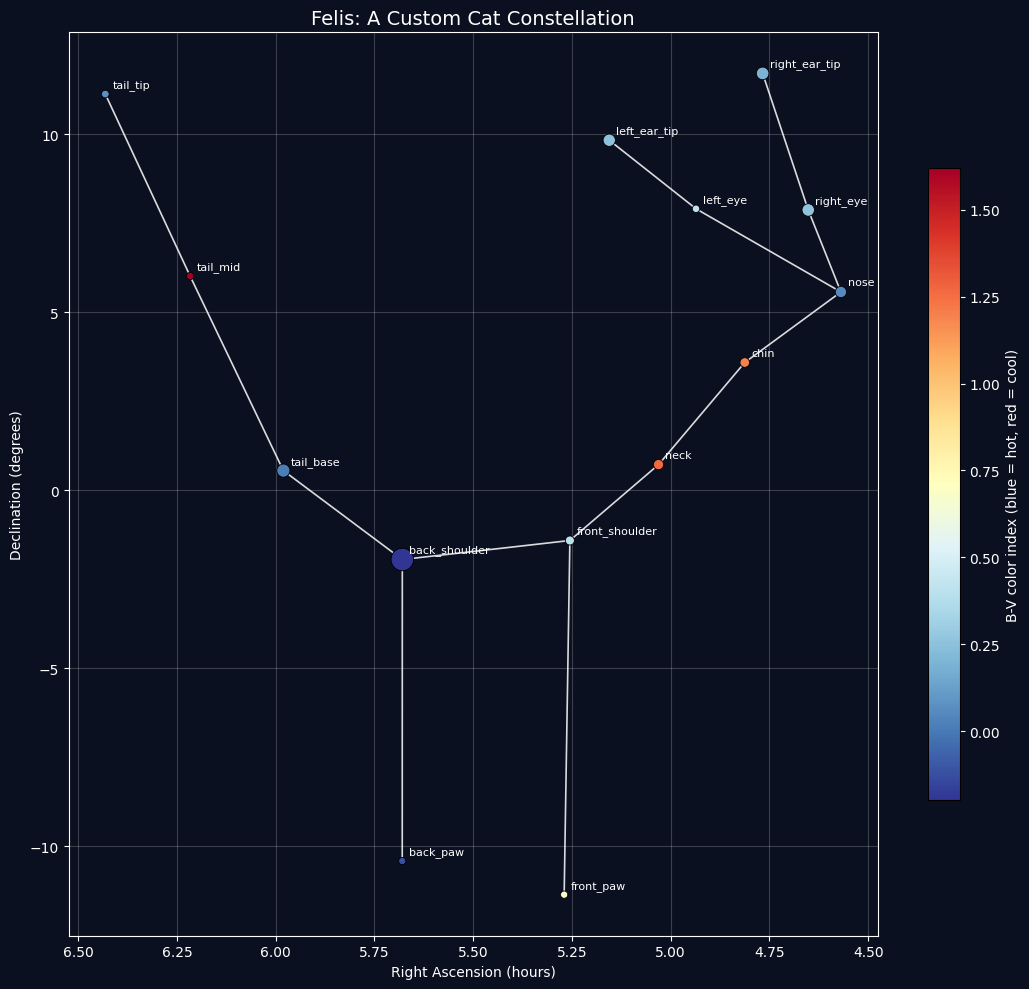

In [34]:
# Question: what does the cat look like when drawn from real stars?
# This plot is the payoff: each anatomy point becomes a real star, sized by how bright it
# appears (mag → size: brighter = bigger) and colored by its B-V color index ci
# (RdYlBu_r colormap → hot/blue stars appear blue, cool/red stars appear red).
# Connecting them with cat_lines turns the dots into a recognizable cat silhouette.
# I invert the x-axis because by convention RA increases to the left in sky charts.

# Build a quick lookup: body_part → row in cat_stars
parts_lookup = cat_stars.set_index('body_part')

fig, ax = plt.subplots(figsize=(11, 10))

# Point sizes: brighter (lower mag) → bigger marker. Floor at a small positive size.
sizes = ((7 - cat_stars['mag']).clip(lower=0.5)) * 50

scatter = ax.scatter(
    cat_stars['ra'],
    cat_stars['dec'],
    s=sizes,
    c=cat_stars['ci'],
    cmap='RdYlBu_r',
    edgecolor='black',
    linewidth=0.6,
    zorder=3,
)

# Draw the connection lines between matched real stars.
for part_a, part_b in cat_lines:
    if part_a in parts_lookup.index and part_b in parts_lookup.index:
        ra_a, dec_a = parts_lookup.loc[part_a, ['ra', 'dec']]
        ra_b, dec_b = parts_lookup.loc[part_b, ['ra', 'dec']]
        ax.plot([ra_a, ra_b], [dec_a, dec_b],
                color='white', linewidth=1.2, alpha=0.85, zorder=2)

# Label each star with its body part.
for _, row in cat_stars.iterrows():
    ax.annotate(
        row['body_part'],
        xy=(row['ra'], row['dec']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        color='white',
        zorder=4,
    )

ax.set_facecolor('#0b1020')          # night-sky background
fig.patch.set_facecolor('#0b1020')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

ax.set_xlabel('Right Ascension (hours)', color='white')
ax.set_ylabel('Declination (degrees)', color='white')
ax.set_title('Felis: A Custom Cat Constellation', color='white', fontsize=14)
ax.invert_xaxis()                    # RA increases to the left (astronomical convention)
ax.grid(True, alpha=0.2, color='white')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('B-V color index (blue = hot, red = cool)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.show()

In [35]:
# Question: what's the hand-off to a renderer?
# This summary lists each body part with the real star backing it: a name (or catalog ID),
# its apparent magnitude (how bright it looks), and its spectral class (color/temperature).
# A renderer can take this list, draw each star at the right size and color, and connect
# them with cat_lines to produce Felis on a real sky chart.

print("Felis — the cat constellation, star by star")
print("=" * 78)
for _, row in cat_stars.iterrows():
    # Best available identifier: proper name → HIP → HD → fallback
    proper = row['proper'] if isinstance(row['proper'], str) and row['proper'].strip() else ''
    if proper:
        ident = proper
    elif row['hip'] not in ('', None) and not (isinstance(row['hip'], float) and pd.isna(row['hip'])):
        ident = f"HIP {int(row['hip'])}" if str(row['hip']).strip() != '' else 'unnamed'
    elif row['hd'] not in ('', None) and not (isinstance(row['hd'], float) and pd.isna(row['hd'])):
        ident = f"HD {int(row['hd'])}" if str(row['hd']).strip() != '' else 'unnamed'
    else:
        ident = 'unnamed star'

    spect = row['spect'] if isinstance(row['spect'], str) and row['spect'].strip() else 'unknown'
    print(f"  {row['body_part']:16s} → {ident:22s}  mag={row['mag']:5.2f}  spect={spect}")

print("=" * 78)
print(f"Total: {len(cat_stars)} real stars, connected by {len(cat_lines)} lines, "
      f"all within the {ra_min:.1f}h–{ra_max:.1f}h RA, "
      f"{dec_min:+d}°…{dec_max:+d}° Dec patch of sky.")

Felis — the cat constellation, star by star
  left_ear_tip     → HIP 23983               mag= 5.43  spect=A2m
  right_ear_tip    → HIP 22157               mag= 5.35  spect=Am...
  left_eye         → HIP 22938               mag= 6.42  spect=F5
  right_eye        → HIP 21670               mag= 5.38  spect=A5m
  nose             → HIP 21295               mag= 5.67  spect=A2Vs
  chin             → HIP 22354               mag= 6.04  spect=K1III
  neck             → HIP 23408               mag= 5.91  spect=K0
  front_shoulder   → HIP 24493               mag= 6.15  spect=F0IV
  back_shoulder    → Alnitak                 mag= 1.74  spect=O9.5Ib SB
  front_paw        → HIP 24560               mag= 6.45  spect=G0
  back_paw         → HIP 26728               mag= 6.46  spect=B9.5IIIp Si
  tail_base        → HIP 28296               mag= 5.21  spect=A1Vs
  tail_mid         → HIP 29509               mag= 6.45  spect=M...
  tail_tip         → HIP 30602               mag= 6.39  spect=A0
Total: 14 real